# 07 · Forecast monthly review volume and rating (zero-shot, no training)

**Use case.** Community managers staff the moderation queue a few months ahead — how many reviews will arrive per month, and is the average rating drifting? Nothing is trained: Chronos-2 forecasts the project's own series on the spot.

**Model / lane:** Chronos-2 zero-shot over `review_time`

**What you will learn**
1. Forecast the monthly review **count** with 10 / 50 / 90 % quantiles and draw the band after the history
2. Forecast the **mean rating** the same way
3. Split a forecast by a category (`category_col`) — verified vs unverified reviews
4. Read the response's calibration flag and warnings, and what a forecast costs

**What this costs.** no training; each forecast call costs 40 + 6 × horizon credits (6 months → 76 credits); a category split costs that × `max_categories`.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
before = credits_used(ls)
review = p.table("review").to_pandas(); review["review_time"] = pd.to_datetime(review["review_time"])
monthly = review.set_index("review_time").resample("ME")["rating"].agg(["count", "mean"])
monthly.tail(6)

reusing project 0b6ffd93-08da-4220-9dfa-5b62b5f5951f (amazon-reviews-explore, status=schema_done)
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


,count,mean
review_time,,
2018-04-30,80,4.462500
2018-05-31,36,4.277778
2018-06-30,4,4.250000
2018-07-31,3,5.000000
2018-08-31,1,5.000000
2018-09-30,1,3.000000


The sample runs 2008 → September 2018 and thins out in its last months (80 → 36 → 4 → 3 → 1 → 1 reviews). A forecaster should follow that tail — watch the median hug zero while the upper quantile keeps the earlier level in play.

target: rating (count) · window: month × len 6 · calibrated: True
  2018-10-01  median 0.0  band [0.0, 24.2]
  2018-11-01  median 0.0  band [0.0, 17.2]
  2018-12-01  median 0.0  band [0.0, 21.6]
  2019-01-01  median 0.0  band [0.0, 25.8]
  2019-02-01  median 0.0  band [0.0, 34.6]
  2019-03-01  median 0.0  band [0.0, 49.2]
warnings: ['window_type_override_mismatch', 'aggregated_to_window']


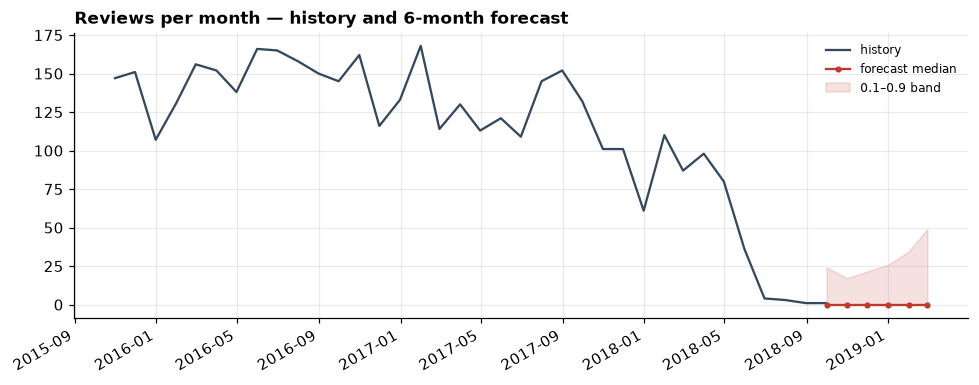

In [3]:
fc = ls.predict.forecast(project_id=p.id, target="rating", agg="count", window="month", length=6, quantiles=[0.1, 0.5, 0.9])
print("target:", fc["target"], "(count) · window:", fc["window_type"], "× len", fc["window_length"], "· calibrated:", fc.get("calibrated"))
for pt in fc["forecast"]:
    q = pt["quantiles"]
    print(f"  {str(pt['timestamp'])[:10]}  median {pt['median']:.1f}  band [{float(q['0.1']):.1f}, {float(q['0.9']):.1f}]")
print("warnings:", [w["code"] for w in fc.get("warnings", [])])
fig(viz.forecast(fc, history=monthly["count"].tail(36), title="Reviews per month — history and 6-month forecast"))

mean rating per month, next 6: [4.09, 4.22, 4.27, 4.21, 4.21, 4.24]


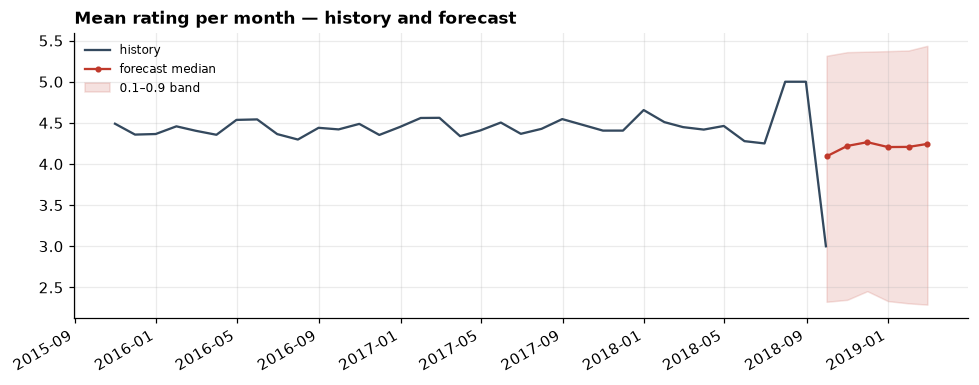

In [4]:
fr = ls.predict.forecast(project_id=p.id, target="rating", agg="mean", window="month", length=6, quantiles=[0.1, 0.5, 0.9])
print("mean rating per month, next 6:", [round(pt["median"], 2) for pt in fr["forecast"]])
fig(viz.forecast(fr, history=monthly["mean"].tail(36), title="Mean rating per month — history and forecast"))

`category_col` splits the series and forecasts each category — here verified vs unverified reviews. Each entry in `series` is a full forecast of its own. **Billing:** a split call costs the single-series fee × `max_categories` (default 8, up to 12), whatever the actual number of values — pass `max_categories` equal to the number of values you expect to pay for exactly those.

2 categories: ['verified=0', 'verified=1']


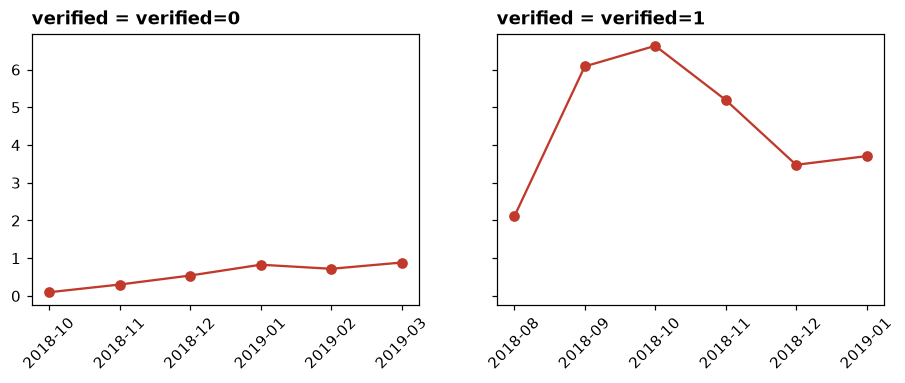

In [5]:
fs = ls.predict.forecast(project_id=p.id, target="rating", agg="count", window="month", length=6, quantiles=[0.1, 0.5, 0.9], category_col="verified", max_categories=2)
print(fs.get("n_categories"), "categories:", [(s.get("label") or s.get("category")) for s in fs.get("series", [])])
import matplotlib.pyplot as plt
f, axes = plt.subplots(1, max(1, len(fs.get("series", []))), figsize=(10, 3.2), sharey=True)
for ax, s in zip(axes if hasattr(axes, "__len__") else [axes], fs.get("series", [])):
    pts = s.get("forecast") or []
    ax.plot([str(x["timestamp"])[:7] for x in pts], [x["median"] for x in pts], marker="o", color="#c0392b")
    ax.set_title(f"verified = {s.get('label') or s.get('category')}", loc="left", fontweight="bold"); ax.tick_params(axis="x", rotation=45)
fig(f)

In [6]:
charged = credits_used(ls) - before
print("credits for the three calls:", charged, "· expected (40 + 6×6) × (1 + 1 + 2 categories) =", 76 * 4)
save_metrics(".", {"notebook": "07_forecast_review_volume", "task": "forecast · monthly review count + mean rating (zero-shot)", "model": "Chronos-2 (zero-shot)",
                   "project_id": p.id, "credits_charged_this_run": charged,
                   "headline": {"horizon_months": fc["window_length"], "calibrated": fc.get("calibrated"),
                                "next_month_reviews_median": round(fc["forecast"][0]["median"], 2), "next_month_mean_rating_median": round(fr["forecast"][0]["median"], 2),
                                "note": "zero-shot: no held-out metric by design"}})

credits for the three calls: 304 · expected (40 + 6×6) × (1 + 1 + 2 categories) = 304
wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [10 · Credits & estimates](../10_credits_estimates_and_errors/) — every price before you pay it